# Setup (assuming you have conda installed):

```
conda create -n miint-tutorial -c conda-forge python=3.11 duckdb python-duckdb pandas numpy scikit-bio scikit-learn matplotlib jupyterlab ipykernel -y

conda run -n miint-tutorial python -m ipykernel install --user --name miint-tutorial --display-name "Python (miint-tutorial)"

conda run -n miint-tutorial jupyter lab
```

# Metagenomic Analysis with MIINT, scikit-bio, and scikit-learn

End-to-end tutorial on real HMP2 / IBDMDB shotgun metagenomic data:

  1. Fetch handful of IBD-relevant gut bacterial reference genomes from NCBI.
  2. Stream 10 paired-end shotgun samples (5 CD, 5 nonIBD) from EBI,
     subsampling to 10k read pairs each for tutorial speed.
  3. Align samples to references with minimap2
  4. Quality-filter and build a sample-by-feature OGU table.
  5. Compute depths per reference to then compare with metatranscriptomics

In [38]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.spatial.distance import pdist, squareform
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.composition import clr, multi_replace
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve, roc_auc_score


READS_PER_SAMPLE = 10_000  # paired-end pairs


def banner(title):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


# ---------------------------------------------------------------------------
banner("Setup: connect to DuckDB and load extensions")
# ---------------------------------------------------------------------------

# DuckDB is an in-process analytic database — think SQLite for analytics.
# `httpfs` lets it read files over HTTP/S3; `miint` adds bioinformatics
# functions (FASTQ readers, aligners, coverage math, etc.).
con = duckdb.connect(config={"allow_unsigned_extensions": "true"})
con.sql("INSTALL httpfs; LOAD httpfs;")
con.execute("force install miint from 'https://ftp.microbio.me/pub/miint'; load miint;")
print("DuckDB:", duckdb.__version__)


Setup: connect to DuckDB and load extensions
DuckDB: 1.5.2


In [39]:
# ---------------------------------------------------------------------------
banner("Step 1: Fetch IBD-relevant reference genomes from NCBI")
# ---------------------------------------------------------------------------

# A "reference" is a known bacterial genome we'll match reads against —
# it's how we identify which microbes a sample contains. We pick 10
# well-studied gut bacteria with complete single-contig genomes,
# spanning species known to be depleted in IBD (F. prausnitzii,
# A. muciniphila, E. rectale) and species known to be enriched in IBD
# (E. coli, C. difficile), plus common Bacteroides.
references = {
    "ecoli_k12":      "U00096.3",    # Escherichia coli K-12 MG1655
    "bfragilis":      "CR626927.1",  # Bacteroides fragilis NCTC 9343
    "btheta":         "AE015928.1",  # Bacteroides thetaiotaomicron VPI-5482
    "bvulgatus":      "CP000139.1",  # Bacteroides vulgatus ATCC 8482
    "amuciniphila":   "CP001071.1",  # Akkermansia muciniphila ATCC BAA-835
    "erectale":       "CP001107.1",  # Agathobacter (Eubacterium) rectalis
    "badolescentis":  "AP009256.1",  # Bifidobacterium adolescentis ATCC 15703
    "cdifficile":     "AM180355.1",  # Clostridioides difficile 630
    "fprausnitzii":   "CP030777.1",  # Faecalibacterium prausnitzii APC918/95b
    "lrhamnosus_gg":  "FM179322.1",  # Lactobacillus rhamnosus GG ATCC 53103
    "mgnavus": "GCF_009831375.1", # Mediterraneibacter gnavus ATCC 29149
    "afinegoldii": "GCF_000265365.1", # Alistipes finegoldii DSM 17242
    "svariabile": "GCF_025152575.1", # Subdoligranulum variabile DSM 15176
    "rintestinalis": "GCF_900537995.1", # Roseburia intestinalis L1-82
    "rhominis": "GCF_000225345.1", # Roseburia hominis A2-183
    "mtorques": "GCF_044591705.1", # Mediterraneibacter torques	CIP112193
    "ebolteae": "GCF_000371705.1", # Enterocloster bolteae 90A9
    "hhathewayi": "GCF_025149285.1", # Hungatella hathewayi	DSM 13479
    "scopri": "GCF_025151535.1" # Segatella copri DSM 18205
}

# Short, human-readable label per genome — used in plots/printouts instead
# of opaque NCBI contig accessions like NC_018011.1.
SPECIES_LABEL = {
    "ecoli_k12":     "E. coli K-12",
    "bfragilis":     "B. fragilis",
    "btheta":        "B. thetaiotaomicron",
    "bvulgatus":     "B. vulgatus",
    "amuciniphila":  "A. muciniphila",
    "erectale":      "A. rectalis",
    "badolescentis": "B. adolescentis",
    "cdifficile":    "C. difficile",
    "fprausnitzii":  "F. prausnitzii",
    "lrhamnosus_gg": "L. rhamnosus GG",
    "mgnavus":       "M. gnavus",
    "afinegoldii":   "A. finegoldii",
    "svariabile":    "S. variabile",
    "rintestinalis": "R. intestinalis",
    "rhominis":      "R. hominis",
    "mtorques":      "M. torques",
    "ebolteae":      "E. bolteae",
    "hhathewayi":    "H. hathewayi",
    "scopri":        "S. copri",
}


con.sql("""
    CREATE OR REPLACE TABLE refs (
        read_id   VARCHAR,
        sequence1 VARCHAR,
        genome_id VARCHAR
    );
""")

for genome_id, accession in references.items():
    con.execute(
        """
        INSERT INTO refs
        SELECT read_id, sequence1, ? AS genome_id
        FROM read_ncbi_fasta(?);
        """,
        [genome_id, accession],
    )

# Build a contig_id -> species_label map. feature_table columns are the
# contig accessions (read_id from each FASTA), so this dict is what we use
# to swap them for human-readable names downstream.
feature_to_species = {
    row["read_id"]: SPECIES_LABEL[row["genome_id"]]
    for _, row in con.sql("SELECT read_id, genome_id FROM refs").df().iterrows()
}

print(con.sql("""
    SELECT genome_id, read_id AS contig_id, length(sequence1) AS length_bp
    FROM refs
    ORDER BY genome_id;
""").df().to_string(index=False))



Step 1: Fetch IBD-relevant reference genomes from NCBI
    genome_id     contig_id  length_bp
  afinegoldii   NC_018011.1    3734239
 amuciniphila    CP001071.1    2664102
badolescentis    AP009256.1    2089645
    bfragilis    CR626927.1    5205140
       btheta    AE015928.1    6260361
    bvulgatus    CP000139.1    5163189
   cdifficile    AM180355.1    4290252
     ebolteae NZ_KB851182.1    6377378
    ecoli_k12      U00096.3    4641652
     erectale    CP001107.1    3449685
 fprausnitzii    CP030777.1    2970937
   hhathewayi NZ_CP102274.1    6931886
lrhamnosus_gg    FM179322.1    3010111
      mgnavus NZ_CP027002.1    3549191
     mtorques NZ_CP172594.1    2979783
     rhominis   NC_015977.1    3592125
rintestinalis NZ_LR027880.1    4493348
       scopri NZ_CP102288.1    3325514
   svariabile NZ_CP102293.1    3244954


In [40]:
# ---------------------------------------------------------------------------
banner("Step 2: Load HMP2 / IBDMDB shotgun samples")
# ---------------------------------------------------------------------------

# Each "sample" is a stool specimen that's been shotgun-sequenced: the DNA
# is randomly fragmented and read in millions of short pieces (reads).
# We use 10 baseline samples from the HMP2/IBDMDB study — 5 with Crohn's
# disease (CD), 5 healthy (nonIBD), one per participant for independence.
samples_meta = pd.DataFrame([
    ("SRR5935860", "C3001C11",   "C3001",   "CD",     20),
    ("SRR5935841", "C3002C9",    "C3002",   "CD",     16),
    ("SRR5936088", "C3008C5",    "C3008",   "CD",      8),
    ("SRR5936186", "C3009C4",    "C3009",   "CD",      6),
    ("SRR5936179", "C3010C2",    "C3010",   "CD",      2),                                                                                                                                                                                                           
    ("SRR5935773", "M2077C2",   "M2077",   "nonIBD",  5),                                                                                                                                        
    ("SRR5936201", "P6017C4",   "P6017",   "nonIBD",  6),                                                                                                                                        
    ("SRR5947081", "M2075C9",   "M2075",   "nonIBD", 14),                                                                                                                                        
    ("SRR5935827", "M2041C2",   "M2041",   "nonIBD",  2),                                                                                                                                        
    ("SRR5947072", "M2084C13",  "M2084",   "nonIBD", 25)                                                                                                                                        
], columns=["run", "sample", "participant", "diagnosis", "week"])


def fastq_urls(run):
    # EBI layout: vol1/fastq/<6-char prefix>/<NNN>/<run>/<run>_{1,2}.fastq.gz
    # NNN is the digits beyond the first 6 of the numeric suffix, zero-padded
    # to 3 chars. So SRR5946700 -> "0", padded -> "000".
    suffix = run[3:]
    n_extra = max(0, len(suffix) - 6)
    nnn = suffix[-n_extra:].zfill(3) if n_extra else ""
    base = f"https://ftp.sra.ebi.ac.uk/vol1/fastq/{run[:6]}/{nnn}/{run}"
    return f"{base}/{run}_1.fastq.gz", f"{base}/{run}_2.fastq.gz"


samples_meta[["url1", "url2"]] = samples_meta["run"].apply(
    lambda r: pd.Series(fastq_urls(r))
)
print(samples_meta[["run", "sample", "diagnosis", "week"]]
      .to_string(index=False))


# Stream reads directly from EBI's public FTP into DuckDB. Paired-end
# sequencing produces two files per sample (_1 and _2) — the two ends of
# each DNA fragment. We cap each sample at READS_PER_SAMPLE pairs so the
# tutorial finishes in minutes; production runs would use everything.
# Read IDs are prefixed with the run accession so they stay unique across
# samples after we pile them into one table.
con.sql("""
    CREATE OR REPLACE TABLE reads (
        sample_id VARCHAR,
        read_id   VARCHAR,
        sequence1 VARCHAR,
        sequence2 VARCHAR
    );
""")

print(f"\nLoading up to {READS_PER_SAMPLE:,} read pairs per sample...")
for row in samples_meta.itertuples(index=False):
    print(f"  {row.run} ({row.diagnosis})...", flush=True)
    con.execute(
        """
        INSERT INTO reads
        SELECT ? AS sample_id,
               ? || '|' || read_id AS read_id,
               sequence1, sequence2
        FROM read_fastx(?, sequence2=?)
        LIMIT ?;
        """,
        [row.run, row.run, row.url1, row.url2, READS_PER_SAMPLE],
    )

print(con.sql("""
    SELECT sample_id, count(*) AS n_pairs
    FROM reads
    GROUP BY sample_id
    ORDER BY sample_id;
""").df().to_string(index=False))


Step 2: Load HMP2 / IBDMDB shotgun samples
       run   sample diagnosis  week
SRR5935860 C3001C11        CD    20
SRR5935841  C3002C9        CD    16
SRR5936088  C3008C5        CD     8
SRR5936186  C3009C4        CD     6
SRR5936179  C3010C2        CD     2
SRR5935773  M2077C2    nonIBD     5
SRR5936201  P6017C4    nonIBD     6
SRR5947081  M2075C9    nonIBD    14
SRR5935827  M2041C2    nonIBD     2
SRR5947072 M2084C13    nonIBD    25

Loading up to 10,000 read pairs per sample...
  SRR5935860 (CD)...
  SRR5935841 (CD)...
  SRR5936088 (CD)...
  SRR5936186 (CD)...
  SRR5936179 (CD)...
  SRR5935773 (nonIBD)...
  SRR5936201 (nonIBD)...
  SRR5947081 (nonIBD)...
  SRR5935827 (nonIBD)...
  SRR5947072 (nonIBD)...
 sample_id  n_pairs
SRR5935773    10000
SRR5935827    10000
SRR5935841    10000
SRR5935860    10000
SRR5936088    10000
SRR5936179    10000
SRR5936186    10000
SRR5936201    10000
SRR5947072    10000
SRR5947081    10000


In [41]:
# ---------------------------------------------------------------------------
banner("Step 3: Align reads (paired-end) against the references")
# ---------------------------------------------------------------------------

# Alignment = finding where each read came from in our reference genomes.
# minimap2 is a fast aligner; preset='sr' is tuned for short paired-end
# reads. max_secondary=5 lets a read report up to 5 near-tie hits, which
# we'll later distribute fractionally across the matched genomes.
con.sql("""
    CREATE OR REPLACE TABLE alignments AS
    WITH hits AS (
        SELECT *
        FROM align_minimap2(
            'reads',
            subject_table='refs',
            preset='sr',
            max_secondary=5
        )
    )
    SELECT r.sample_id, h.*
    FROM hits h
    JOIN reads r USING (read_id);
""")

print(con.sql("""
    SELECT sample_id, count(*) AS n_alignments
    FROM alignments
    GROUP BY sample_id
    ORDER BY sample_id;
""").df().to_string(index=False))


Step 3: Align reads (paired-end) against the references
 sample_id  n_alignments
SRR5935773          7832
SRR5935827          7325
SRR5935841         12707
SRR5935860          9737
SRR5936088          8850
SRR5936179          6628
SRR5936186         13727
SRR5936201         10258
SRR5947072          5265
SRR5947081          4104


In [42]:
# ---------------------------------------------------------------------------
banner("Step 4: Quality-filter and build a feature table")
# ---------------------------------------------------------------------------

# Drop low-quality and ambiguous alignments before counting:
#   - is_primary: keep only the best alignment per read (drop secondaries)
#   - query_coverage >= 0.9: at least 90% of the read aligned (no clipped junk)
#   - seq_identity >= 0.95: at least 95% of aligned bases match the reference
con.sql("""
  CREATE OR REPLACE VIEW filtered_alignments AS
  SELECT *
  FROM alignments
  WHERE alignment_is_primary(flags)
    AND cigar_query_coverage(cigar) >= 0.9
    AND alignment_seq_identity(cigar, tag_nm, tag_md, 'blast') >= 0.95;
""")

# Build an "OGU" (Operational Genomic Unit) feature table using woltka_ogu.
# It implements Woltka's classification: each read's count is split 1/N across
# the N references it maps to (within the same orientation), then summed per
# (sample, feature). Passing sample_id := 'sample_id' runs one aggregation per
# sample in parallel.
long_table = con.sql("""
  SELECT sample_id, feature_id, value
  FROM woltka_ogu('filtered_alignments', 'read_id', sample_id := 'sample_id')
  ORDER BY sample_id, feature_id;
""").df()

feature_table = (
    long_table
    .pivot(index="sample_id", columns="feature_id", values="value")
    .fillna(0.0)
    .reindex(samples_meta["run"].tolist())
    .fillna(0.0)
)

# Swap opaque contig accessions for short species labels.
feature_table = feature_table.rename(columns=feature_to_species)

print("\nFeature table (samples x features):")
feature_table



Step 4: Quality-filter and build a feature table

Feature table (samples x features):


feature_id,B. thetaiotaomicron,C. difficile,B. adolescentis,B. vulgatus,A. muciniphila,A. rectalis,F. prausnitzii,B. fragilis,L. rhamnosus GG,R. hominis,A. finegoldii,M. gnavus,H. hathewayi,S. copri,S. variabile,M. torques,E. bolteae,R. intestinalis,E. coli K-12
sample_id,,,,,,,,,,,,,,,,,,,
SRR5935860,1124.0,3.0,0.0,6133.0,24.0,37.0,211.0,189.0,0.0,28.0,14.0,28.0,44.0,3.0,7.0,90.0,394.0,37.0,6.0
SRR5935841,1545.0,0.0,0.0,6584.0,0.0,76.0,2.0,1473.0,0.0,7.0,64.0,4.0,47.0,63.0,0.0,6.0,1298.0,6.0,6.0
SRR5936088,44.0,1.0,0.0,6491.0,0.0,12.0,2.0,32.0,0.0,211.0,43.0,11.0,9.0,7.0,7.0,5.0,227.0,17.0,1.0
SRR5936186,0.0,8.0,0.0,40.0,0.0,121.0,24.0,0.0,0.0,271.0,0.0,159.0,76.0,0.0,34.0,46.0,17.0,9430.0,771.0
SRR5936179,771.0,4.0,0.0,3558.0,0.0,191.0,227.0,8.0,0.0,74.0,183.0,6.0,29.0,4.0,11.0,18.0,27.0,141.0,0.0
SRR5935773,518.0,2.0,0.0,5063.0,0.0,4.0,82.0,453.0,0.0,17.0,224.0,31.0,19.0,0.0,9.0,13.0,23.0,17.0,4.0
SRR5936201,105.0,5.0,0.0,499.0,78.0,186.0,221.0,36.0,0.0,62.0,45.0,16.0,19.0,6455.0,16.0,20.0,6.0,134.0,0.0
SRR5947081,146.0,15.0,25.0,1002.0,0.0,343.0,116.0,15.0,0.0,129.0,63.0,49.0,14.0,1.0,21.0,118.0,42.0,187.0,0.0
SRR5935827,355.0,8.0,30.0,3434.0,1503.0,121.0,25.0,135.0,2.0,46.0,346.0,9.0,22.0,3.0,3.0,2.0,15.0,19.0,8.0


In [43]:
# ---------------------------------------------------------------------------
banner("Step 5: Save outputs for the MTX comparison tutorial")
# ---------------------------------------------------------------------------

# The subsequent MTX steps read these to contrast metagenomic vs
# metatranscriptomic profiles for the SAME 10 samples.

samples_meta[["run", "sample", "participant", "diagnosis", "week"]].to_csv(
    "mgx_samples.csv", index=False
)
feature_table.to_csv("mgx_feature_table.csv")
print("Saved sample sheet -> mgx_samples.csv")
print("Saved feature table -> mgx_feature_table.csv")

# Per-position depth = how many reads cover each base of the genome.
# We compute it for the (sample, reference) pair with the most
# alignments. The subsequent MTX steps will plot this next to its own depth
# profile: shotgun DNA gives roughly uniform coverage everywhere,
# while RNA piles up only on actively transcribed genes.
top = (
    long_table.sort_values("value", ascending=False)
    .iloc[0][["sample_id", "feature_id"]]
    .to_dict()
)
top_label = feature_to_species.get(top["feature_id"], top["feature_id"])
print(f"Computing MGX depth for sample={top['sample_id']} ref={top_label}")

ref_len = con.execute(
    "SELECT length(sequence1) FROM refs WHERE read_id = ?",
    [top["feature_id"]],
).fetchone()[0]

depth_df = con.execute(
    """
    WITH agg AS (
        SELECT compute_coverage_depth(position, stop_position, cigar, ?,
                                      'exclude_deletions') AS depth_list
        FROM filtered_alignments
        WHERE sample_id = ? AND reference = ?
    )
    SELECT pos, depth_list[pos] AS depth
    FROM agg, generate_series(1, len(depth_list)) AS t(pos);
    """,
    [ref_len, top["sample_id"], top["feature_id"]],
).df()

depth_df.attrs["sample_id"] = top["sample_id"]
depth_df.attrs["reference"] = top["feature_id"]
depth_df.to_csv("mgx_depth_top.csv", index=False)
# .meta stores the raw contig accession (needed for SQL in the MTX step) plus
# the species label for display.
with open("mgx_depth_top.meta", "w") as f:
    f.write(f"{top['sample_id']}\t{top['feature_id']}\t{ref_len}\t{top_label}\n")
print(f"Saved depth profile -> mgx_depth_top.csv ({len(depth_df)} positions)")


Step 5: Save outputs for the MTX comparison tutorial
Saved sample sheet -> mgx_samples.csv
Saved feature table -> mgx_feature_table.csv
Computing MGX depth for sample=SRR5936186 ref=R. intestinalis
Saved depth profile -> mgx_depth_top.csv (4493348 positions)


# PART 2: Metatranscriptomic (MTX)

Same as the metagenomics (MGX) tutorial, except run on the paired
RNA-Seq libraries from the same 10 HMP2 samples (5 CD, 5 nonIBD).
We will then read the MGX outputs and contrasts them with MTX:

  1. Fetch the same IBD-relevant gut bacterial reference genomes.
  2. Stream 10 paired-end RNA-Seq samples (5 CD, 5 nonIBD) from EBI,
     subsampling to 100k read pairs each.
  3. Align with minimap2
  4. Quality-filter and build a sample-by-feature OGU table.
  5. Compare to MGX:
       - Per-position depth profile for one (sample, reference): MGX is
         roughly flat across the genome, MTX is spiky and gene-focused.
       - MTX/MGX activity ratio per (taxon, participant): which lineages
         are over- or under-transcribed relative to their abundance.

In [44]:
# ---------------------------------------------------------------------------
banner("Step 1: Load HMP2 / IBDMDB metatranscriptomic samples")
# ---------------------------------------------------------------------------

# Metatranscriptomics (MTX) sequences the *RNA* in a stool sample
# instead of the DNA. DNA tells you which microbes are present; RNA
# tells you which ones are actively expressing genes. These 10 RNA-Seq 
# libraries come from the same 10 stool specimens as the MGX tutorial (matched by sample)
samples_meta = pd.DataFrame([
    # mtx_run,    sample, participant, diagnosis, week
    ("SRR5949159", "C3001C11",   "C3001",   "CD",     20),
    ("SRR5949371", "C3002C9",    "C3002",   "CD",     16),
    ("SRR5949282", "C3008C5",    "C3008",   "CD",      8),
    ("SRR5949376", "C3009C4",    "C3009",   "CD",      6),
    ("SRR5949473", "C3010C2",    "C3010",   "CD",      2),
    ("SRR5949245", "M2077C2",   "M2077",   "nonIBD",  5),                                                                                                                                        
    ("SRR5949382", "P6017C4",   "P6017",   "nonIBD",  6),                                                                                                                                        
    ("SRR5950253", "M2075C9",   "M2075",   "nonIBD", 14),                                                                                                                                        
    ("SRR5949286", "M2041C2",   "M2041",   "nonIBD",  2),                                                                                                                                        
    ("SRR5950461", "M2084C13",  "M2084",   "nonIBD", 25)
], columns=["run", "sample", "participant", "diagnosis", "week"])


def fastq_urls(run):
    suffix = run[3:]
    n_extra = max(0, len(suffix) - 6)
    nnn = suffix[-n_extra:].zfill(3) if n_extra else ""
    base = f"https://ftp.sra.ebi.ac.uk/vol1/fastq/{run[:6]}/{nnn}/{run}"
    return f"{base}/{run}_1.fastq.gz", f"{base}/{run}_2.fastq.gz"


samples_meta[["url1", "url2"]] = samples_meta["run"].apply(
    lambda r: pd.Series(fastq_urls(r))
)
print(samples_meta[["run", "sample", "diagnosis", "week"]]
      .to_string(index=False))


# Stream up to READS_PER_SAMPLE pairs from each RNA-Seq library, same
# as MGX. Read IDs are namespaced by run accession to stay unique.
con.sql("""
    CREATE OR REPLACE TABLE reads (
        sample_id VARCHAR,
        read_id   VARCHAR,
        sequence1 VARCHAR,
        sequence2 VARCHAR
    );
""")

print(f"\nLoading up to {READS_PER_SAMPLE:,} read pairs per sample...")
for row in samples_meta.itertuples(index=False):
    print(f"  {row.run} ({row.diagnosis})...", flush=True)
    con.execute(
        """
        INSERT INTO reads
        SELECT ? AS sample_id,
               ? || '|' || read_id AS read_id,
               sequence1, sequence2
        FROM read_fastx(?, sequence2=?)
        LIMIT ?;
        """,
        [row.run, row.run, row.url1, row.url2, READS_PER_SAMPLE],
    )

print(con.sql("""
    SELECT sample_id, count(*) AS n_pairs
    FROM reads
    GROUP BY sample_id
    ORDER BY sample_id;
""").df().to_string(index=False))


Step 1: Load HMP2 / IBDMDB metatranscriptomic samples
       run   sample diagnosis  week
SRR5949159 C3001C11        CD    20
SRR5949371  C3002C9        CD    16
SRR5949282  C3008C5        CD     8
SRR5949376  C3009C4        CD     6
SRR5949473  C3010C2        CD     2
SRR5949245  M2077C2    nonIBD     5
SRR5949382  P6017C4    nonIBD     6
SRR5950253  M2075C9    nonIBD    14
SRR5949286  M2041C2    nonIBD     2
SRR5950461 M2084C13    nonIBD    25

Loading up to 10,000 read pairs per sample...
  SRR5949159 (CD)...
  SRR5949371 (CD)...
  SRR5949282 (CD)...
  SRR5949376 (CD)...
  SRR5949473 (CD)...
  SRR5949245 (nonIBD)...
  SRR5949382 (nonIBD)...
  SRR5950253 (nonIBD)...
  SRR5949286 (nonIBD)...
  SRR5950461 (nonIBD)...
 sample_id  n_pairs
SRR5949159    10000
SRR5949245    10000
SRR5949282    10000
SRR5949286    10000
SRR5949371    10000
SRR5949376    10000
SRR5949382    10000
SRR5949473    10000
SRR5950253    10000
SRR5950461    10000


In [45]:
# ---------------------------------------------------------------------------
banner("Step 3: Align RNA reads against the references")
# ---------------------------------------------------------------------------

# Same alignment call as MGX. The 'sr' (short-read) preset is still
# correct here because bacterial mRNA isn't spliced — a cDNA read maps
# to a contiguous chunk of genome just like a DNA read. Splice-aware
# presets ('splice', 'splice:hq') are for eukaryotic transcripts and
# would be wrong for prokaryotes.
con.sql("""
    CREATE OR REPLACE TABLE alignments AS
    WITH hits AS (
        SELECT *
        FROM align_minimap2(
            'reads',
            subject_table='refs',
            preset='sr',
            max_secondary=5
        )
    )
    SELECT r.sample_id, h.*
    FROM hits h
    JOIN reads r USING (read_id);
""")

# Sanity check / first MTX-vs-MGX contrast: what fraction of reads
# actually mapped to a bacterial reference? RNA libraries are dominated
# by ribosomal RNA and human transcripts, so this rate is typically
# much lower than for matched DNA libraries from the same specimens.
align_rate = con.sql("""
    SELECT r.sample_id,
           count(DISTINCT r.read_id) AS n_reads,
           count(DISTINCT a.read_id) AS n_aligned,
           100.0 * count(DISTINCT a.read_id) / count(DISTINCT r.read_id)
               AS pct_aligned
    FROM reads r
    LEFT JOIN alignments a USING (sample_id, read_id)
    GROUP BY r.sample_id
    ORDER BY r.sample_id;
""").df()
print("MTX bacterial-alignment rate per sample:")
print(align_rate.to_string(index=False))


Step 3: Align RNA reads against the references
MTX bacterial-alignment rate per sample:
 sample_id  n_reads  n_aligned  pct_aligned
SRR5949159    10000       7519        75.19
SRR5949245    10000       7977        79.77
SRR5949282    10000       6300        63.00
SRR5949286    10000       7527        75.27
SRR5949371    10000       8220        82.20
SRR5949376    10000       8268        82.68
SRR5949382    10000       7480        74.80
SRR5949473    10000       4802        48.02
SRR5950253    10000       5927        59.27
SRR5950461    10000       5955        59.55


In [46]:
# ---------------------------------------------------------------------------
banner("Step 4: Quality-filter and build a feature table")
# ---------------------------------------------------------------------------

# Same quality filters as MGX: keep only high-coverage, high-identity
# primary alignments before counting.
con.sql("""
  CREATE OR REPLACE VIEW filtered_alignments AS
  SELECT *
  FROM alignments
  WHERE alignment_is_primary(flags)
    AND cigar_query_coverage(cigar) >= 0.9
    AND alignment_seq_identity(cigar, tag_nm, tag_md, 'blast') >= 0.95;
""")

# Build an "OGU" (Operational Genomic Unit) feature table using woltka_ogu.
# Each read's count is split 1/N across the N references it maps to.
long_table = con.sql("""
  SELECT sample_id, feature_id, value
  FROM woltka_ogu('filtered_alignments', 'read_id', sample_id := 'sample_id')
  ORDER BY sample_id, feature_id;
""").df()

feature_table = (
    long_table
    .pivot(index="sample_id", columns="feature_id", values="value")
    .fillna(0.0)
    .reindex(samples_meta["run"].tolist())
    .fillna(0.0)
)

# Swap opaque contig accessions for short species labels.
feature_table = feature_table.rename(columns=feature_to_species)

print("\nMTX feature table (samples x features):")
feature_table



Step 4: Quality-filter and build a feature table

MTX feature table (samples x features):


feature_id,B. thetaiotaomicron,C. difficile,B. adolescentis,B. vulgatus,A. muciniphila,A. rectalis,F. prausnitzii,B. fragilis,L. rhamnosus GG,R. hominis,A. finegoldii,M. gnavus,H. hathewayi,S. copri,S. variabile,M. torques,E. bolteae,R. intestinalis,E. coli K-12
sample_id,,,,,,,,,,,,,,,,,,,
SRR5949159,1177.0,3.0,0.0,8710.0,109.0,55.0,868.0,230.0,0.0,65.0,1.0,18.0,32.0,12.0,16.0,92.0,288.0,86.0,12.0
SRR5949371,1850.0,0.0,1.0,10740.0,0.0,96.0,2.0,1067.0,0.0,32.0,12.0,10.0,12.0,452.0,0.0,1.0,268.0,11.0,6.0
SRR5949282,16.0,0.0,0.0,8190.0,0.0,35.0,7.0,47.0,0.0,404.0,71.0,9.0,18.0,4.0,107.0,5.0,260.0,69.0,0.0
SRR5949376,0.0,67.0,0.0,7.0,0.0,94.0,3.0,2.0,1.0,977.0,0.0,167.0,157.0,1.0,4.0,44.0,81.0,11369.0,1360.0
SRR5949473,730.0,1.0,0.0,4166.0,0.0,166.0,1333.0,139.0,0.0,36.0,412.0,7.0,6.0,31.0,6.0,1.0,2.0,94.0,0.0
SRR5949245,752.0,4.0,0.0,9522.0,0.0,8.0,345.0,401.0,0.0,3.0,307.0,15.0,10.0,8.0,4.0,24.0,19.0,6.0,4.0
SRR5949382,118.0,2.0,0.0,457.0,44.0,106.0,736.0,47.0,0.0,10.0,116.0,7.0,2.0,10132.0,2.0,2.0,6.0,72.0,1.0
SRR5950253,965.0,1.0,23.0,2572.0,0.0,484.0,800.0,425.0,1.0,169.0,533.0,6.0,5.0,13.0,30.0,21.0,8.0,209.0,0.0
SRR5949286,1248.0,14.0,33.0,7169.0,231.0,153.0,118.0,546.0,0.0,71.0,134.0,21.0,32.0,18.0,5.0,27.0,30.0,101.0,6.0



Step 5: Compare MTX to MGX (same 10 samples)

7a. Per-position depth profile: MGX (flat) vs MTX (spiky)
sample:    C3009C4
Reference:        R. intestinalis (4,493,348 bp)
MGX run:          SRR5936186
MTX run:          SRR5949376
MTX depth profile: 4,493,348 positions, max depth = 585
Saved depth comparison -> depth_mgx_vs_mtx.png
Note: MGX coverage is roughly uniform across the genome (random WGS
fragmentation), while MTX coverage spikes at transcribed loci.


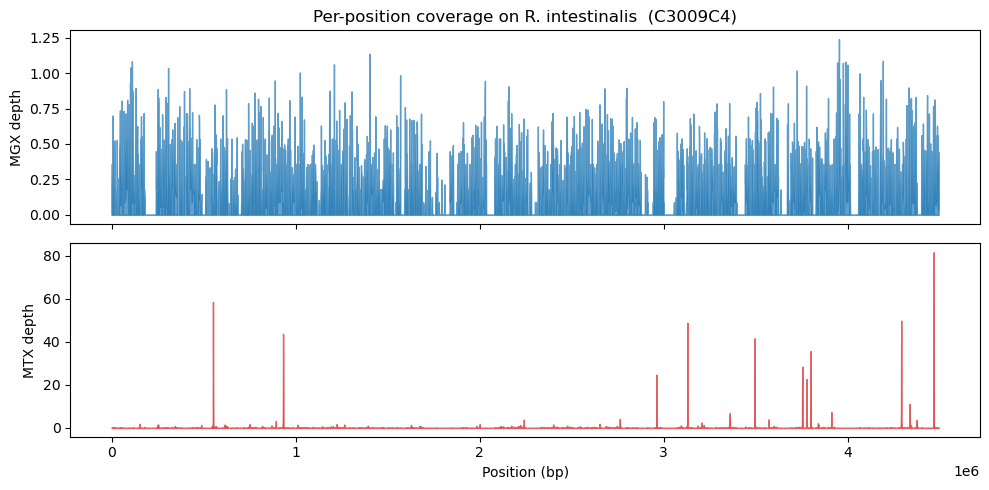

In [47]:
# ---------------------------------------------------------------------------
banner("Step 5: Compare MTX to MGX (same 10 samples)")
# ---------------------------------------------------------------------------

# Step 5 needs the outputs from the MGX steps. If they
# aren't present, exit gracefully with instructions instead of crashing.
required = ["mgx_samples.csv", "mgx_feature_table.csv",
            "mgx_depth_top.csv", "mgx_depth_top.meta"]
missing = [p for p in required if not os.path.exists(p)]
if missing:
    print(f"Skipping comparison — missing MGX outputs: {missing}")
    raise SystemExit(0)

mgx_samples = pd.read_csv("mgx_samples.csv")
mgx_feature = pd.read_csv("mgx_feature_table.csv", index_col=0)
mgx_depth = pd.read_csv("mgx_depth_top.csv")
with open("mgx_depth_top.meta") as f:
    parts = f.read().strip().split("\t")
mgx_top_sample, mgx_top_ref, mgx_top_reflen = parts[0], parts[1], int(parts[2])
# Backwards-compatible: older .meta files don't have the species label column.
mgx_top_label = parts[3] if len(parts) > 3 else feature_to_species.get(
    mgx_top_ref, mgx_top_ref
)


# 7a. Per-position depth: MGX vs MTX for the same (sample, reference).
# The classic visual signature of RNA vs DNA: shotgun DNA reads tile a
# bacterial genome roughly uniformly, while RNA reads pile up only on
# transcribed genes — so MGX coverage looks like a flat plateau and MTX
# coverage looks like a spiky skyline of expressed loci.
banner("7a. Per-position depth profile: MGX (flat) vs MTX (spiky)")

ssc = mgx_samples.set_index("run").loc[mgx_top_sample, "sample"]
mtx_run_for_top = samples_meta.set_index("sample").loc[ssc, "run"]
print(f"sample:    {ssc}")
print(f"Reference:        {mgx_top_label} ({mgx_top_reflen:,} bp)")
print(f"MGX run:          {mgx_top_sample}")
print(f"MTX run:          {mtx_run_for_top}")

mtx_depth_df = con.execute(
    """
    WITH agg AS (
        SELECT compute_coverage_depth(position, stop_position, cigar, ?,
                                      'exclude_deletions') AS depth_list
        FROM filtered_alignments
        WHERE sample_id = ? AND reference = ?
    )
    SELECT pos, depth_list[pos] AS depth
    FROM agg, generate_series(1, len(depth_list)) AS t(pos);
    """,
    [mgx_top_reflen, mtx_run_for_top, mgx_top_ref],
).df()
print(f"MTX depth profile: {len(mtx_depth_df):,} positions, "
      f"max depth = {int(mtx_depth_df['depth'].max() or 0)}")


def downsample(df, n=4000):
    """Bin positions to ~n points so the plot stays readable."""
    if len(df) <= n:
        return df
    bins = np.linspace(0, len(df), n + 1, dtype=int)
    return pd.DataFrame({
        "pos": (bins[:-1] + bins[1:]) // 2,
        "depth": [df["depth"].iloc[bins[i]:bins[i+1]].mean()
                  for i in range(n)],
    })


mgx_plot = downsample(mgx_depth)
mtx_plot = downsample(mtx_depth_df)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].fill_between(mgx_plot["pos"], mgx_plot["depth"], color="#1f77b4", alpha=0.7)
axes[0].set_ylabel("MGX depth")
axes[0].set_title(f"Per-position coverage on {mgx_top_label}  ({ssc})")
axes[1].fill_between(mtx_plot["pos"], mtx_plot["depth"], color="#d62728", alpha=0.7)
axes[1].set_ylabel("MTX depth")
axes[1].set_xlabel("Position (bp)")
plt.tight_layout()
fig.savefig("depth_mgx_vs_mtx.png", dpi=120)
print("Saved depth comparison -> depth_mgx_vs_mtx.png")
print("Note: MGX coverage is roughly uniform across the genome (random WGS")
print("fragmentation), while MTX coverage spikes at transcribed loci.")



7b. MTX/MGX activity ratio per (taxon, participant)
Saved activity-ratio heatmap -> activity_ratio_mtx_vs_mgx.png


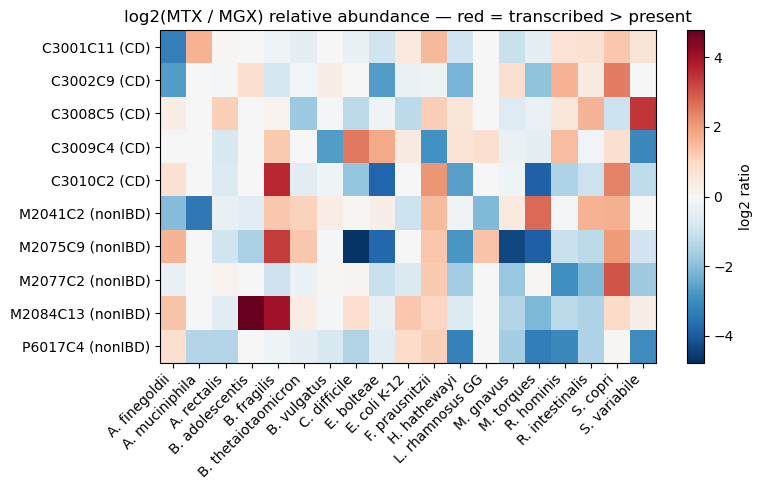

In [48]:
# 7b. MTX/MGX activity ratio per (taxon, participant).
# Normalize each table to relative abundance (so each row sums to 1),
# then take log2(MTX / MGX) per cell. Positive values = a taxon is
# transcribing more than its DNA-level abundance would predict (over-
# active); negative = under-active or dormant. This is the simplest
# version of a "transcriptional activity index".
banner("7b. MTX/MGX activity ratio per (taxon, participant)")


def to_relabund(df):
    totals = df.sum(axis=1).replace(0, np.nan)
    return df.div(totals, axis=0).fillna(0.0)


mtx_rel = to_relabund(feature_table)
mgx_rel = to_relabund(mgx_feature)

# Re-key both tables by sample so we can align the matched pairs.
mtx_ssc_index = (samples_meta.set_index("run")
                 .loc[mtx_rel.index, "sample"].values)
mgx_ssc_index = (mgx_samples.set_index("run")
                 .loc[mgx_rel.index, "sample"].values)
mtx_rel.index = mtx_ssc_index
mgx_rel.index = mgx_ssc_index

shared_sscs = sorted(set(mtx_rel.index) & set(mgx_rel.index))
shared_features = sorted(set(mtx_rel.columns) & set(mgx_rel.columns))
mtx_rel = mtx_rel.loc[shared_sscs, shared_features]
mgx_rel = mgx_rel.loc[shared_sscs, shared_features]

# log2 ratio with a pseudocount so zeros don't blow up.
pseudo = 1e-4
ratio = np.log2((mtx_rel + pseudo) / (mgx_rel + pseudo))

# Order rows by diagnosis for the heatmap.
ssc_to_dx = samples_meta.set_index("sample")["diagnosis"].to_dict()
order = sorted(ratio.index, key=lambda s: (ssc_to_dx[s], s))
ratio = ratio.loc[order]

fig, ax = plt.subplots(figsize=(8, 5))
vmax = float(np.nanmax(np.abs(ratio.values))) or 1.0
im = ax.imshow(ratio.values, aspect="auto", cmap="RdBu_r",
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(ratio.columns)))
ax.set_xticklabels(ratio.columns, rotation=45, ha="right")
ax.set_yticks(range(len(ratio.index)))
ax.set_yticklabels([f"{s} ({ssc_to_dx[s]})" for s in ratio.index])
ax.set_title("log2(MTX / MGX) relative abundance — red = transcribed > present")
fig.colorbar(im, ax=ax, label="log2 ratio")
plt.tight_layout()
fig.savefig("activity_ratio_mtx_vs_mgx.png", dpi=120)
print("Saved activity-ratio heatmap -> activity_ratio_mtx_vs_mgx.png")

*Relative abundance depends on sequencing depth, so this is where the NPH absolute quantification procedure could be much more informative!*

# Part 3: Analyzing a full dataset

Now lets use feature tables from the fully aligned HMP2 dataset across 130 participants and thousands of genomes!
- Compute alpha/beta diversity and a PCoA ordination with scikit-bio.
- Train a random forest to predict diagnosis (IBD vs nonIBD) and plot AUROC.

In [49]:
"""
HMP-IBD tutorial pipeline — IBD vs nonIBD
=========================================
1. Load biom feature tables + mapping file
2. Prevalence/count filtering
3. Alpha diversity — Shannon + Faith's PD, by group
4. Beta diversity:
     * Weighted UniFrac (phylogenetic, requires rarefaction)
     * Robust Aitchison PCA (compositional, no rarefaction) — optional
   visualised with PCoA / biplot, PERMANOVA tested on host_subject_id-aware data
5. Random Forest classifier — subject-grouped CV, ROC curve, permutation
   feature importance aggregated to species

Notes
-----
* HMP-IBD is longitudinal: host_subject_id appears multiple times. Without
  grouping by subject, CV/PERMANOVA estimates are optimistically biased.
* For 1k+ samples, Striped UniFrac (`unifrac` package) is ~100x faster than
  skbio. Swap `beta_diversity("weighted_unifrac", ...)` for
  `unifrac.weighted_unifrac(biom_path, tree_path)` if installed.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from biom import load_table
from skbio import TreeNode
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats import subsample_counts
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
BIOMS = {
    "Metagenomic":        "metaG-feature-table.biom",
    "Metatranscriptomic": "metaT-feature-table.biom",
}
TAX = {
    "Metagenomic":        "metag_taxonomy.tsv",
    "Metatranscriptomic": "metaT_taxonomy.tsv",
}
MAP_PATH  = "hmp-metadata.txt"
TREE_PATH = "tree.nwk"

results = {}

MIN_COUNT     = 10
MIN_PREV      = 0.1
RAREFY_DEPTH  = 5_000
N_FOLDS       = 5
SEED          = 42
TOP_FEATURES  = 20
PALETTE       = {"nonIBD": "#4C9F70", "IBD": "#C0392B"}

In [50]:
# ---------------------------------------------------------------------------
# Step 1 — Load mapping
# ---------------------------------------------------------------------------
print("=" * 70, "\nStep 1: Load mapping file\n", "=" * 70, sep="")
meta = (pd.read_csv(MAP_PATH, sep="\t", dtype=str, low_memory=False)
          .rename(columns={"#SampleID": "SampleID"})
          .set_index("SampleID"))
meta["group"] = meta["diagnosis"].map({"nonIBD": "nonIBD", "CD": "IBD", "UC": "IBD"})
meta = meta.dropna(subset=["group"])
print(f"{len(meta)} samples across {meta['host_subject_id'].nunique()} subjects "
      f"(dedup happens per modality below).")


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def load_and_filter(biom_path):
    X = load_table(biom_path).to_dataframe(dense=True).T
    X.index = X.index.astype(str)
    shared = X.index.intersection(meta.index)
    X = X.loc[shared]
    keep = ((X > 0).mean(0) >= MIN_PREV) & (X.sum(0) >= MIN_COUNT)
    X = X.loc[:, keep]
    print(f"  {X.shape[0]} samples × {X.shape[1]} features after filtering")
    return X


def rarefy_table(X, depth, seed=SEED):
    """Subsample-without-replacement rarefaction. Drops samples below depth."""
    np.random.seed(seed)
    counts = X.values.astype(int)
    totals = counts.sum(1)
    keep = totals >= depth
    X = X.loc[keep]; counts = counts[keep]
    out = np.vstack([subsample_counts(row, depth) for row in counts])
    return pd.DataFrame(out, index=X.index, columns=X.columns)


def shear_tree(tree, names):
    """Return a tree pruned to the given tip names (silent on missing)."""
    present = {t.name for t in tree.tips()} & set(names)
    return tree.shear(present)


def load_tax(path):
    t = pd.read_csv(path, sep="\t", header=None,
                    names=["feature", "lineage"], dtype=str)
    t["species"] = t["lineage"].str.extract(r"s__([^;]+)").iloc[:, 0].str.strip()
    return t.set_index("feature")["species"]


def unifrac_compat(table_df, tree):
    """Call skbio beta_diversity with the right kwarg for the installed version."""
    try:
        return beta_diversity("unweighted_unifrac", table_df.values,
                              ids=table_df.index.tolist(),
                              taxa=table_df.columns.tolist(),
                              tree=tree, validate=False)
    except TypeError:
        return beta_diversity("unweighted_unifrac", table_df.values,
                              ids=table_df.index.tolist(),
                              otu_ids=table_df.columns.tolist(),
                              tree=tree, validate=False)


# ---------------------------------------------------------------------------
# Load full tree once
# ---------------------------------------------------------------------------
print("\nLoading phylogenetic tree...")
full_tree = TreeNode.read(TREE_PATH)
tree_tips = {t.name for t in full_tree.tips()}
print(f"  Tree has {len(tree_tips):,} tips")

Step 1: Load mapping file
1592 samples across 130 subjects (dedup happens per modality below).

Loading phylogenetic tree...
  Tree has 15,953 tips


In [51]:
# ---------------------------------------------------------------------------
# Start with Metagenomics
# ---------------------------------------------------------------------------
label = "Metagenomic"
biom_path = BIOMS[label]
print("\n" + "#" * 70, f"\n# {label}\n", "#" * 70, sep="")

# --- Step 1: load + filter ---
print("\nStep 2: Load + filter feature table")
X = load_and_filter(biom_path)

# Dedup to one random sample per subject
m_all = meta.loc[X.index]
m = (m_all.groupby("host_subject_id", group_keys=False)
          .sample(n=1, random_state=SEED))
X = X.loc[m.index]
print(f"  After per-subject dedup: {X.shape[0]} samples "
      f"({m['host_subject_id'].nunique()} subjects)")

# restrict to features present in reference phylogenetic tree (for diversity metrics)
in_tree = [f for f in X.columns if f in tree_tips]
X_tree = X[in_tree]
sub_tree = shear_tree(full_tree, in_tree)
print(f"  {len(in_tree)} / {X.shape[1]} features present in tree")



######################################################################
# Metagenomic
######################################################################

Step 2: Load + filter feature table
  1592 samples × 3925 features after filtering
  After per-subject dedup: 130 samples (130 subjects)
  3925 / 3925 features present in tree


In [52]:
# --- Step 3: rarefy ---
print(f"\nStep 3: Rarefy to {RAREFY_DEPTH:,} (subsample without replacement)")
X_rare = rarefy_table(X_tree, RAREFY_DEPTH)
m_rare = m.loc[X_rare.index]
print(f"  {X_rare.shape[0]} samples retained "
      f"({(m_rare['group']=='IBD').sum()} IBD, "
      f"{(m_rare['group']=='nonIBD').sum()} nonIBD)")


Step 3: Rarefy to 5,000 (subsample without replacement)
  130 samples retained (103 IBD, 27 nonIBD)



Step 4: Alpha diversity (Shannon + Faith's PD)


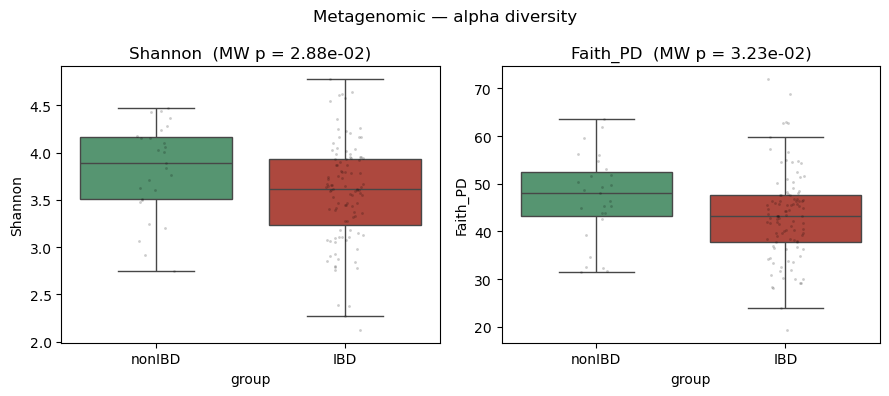

In [53]:
# --- Step 4: alpha diversity (Shannon + Faith's PD) ---
print("\nStep 4: Alpha diversity (Shannon + Faith's PD)")
shannon = alpha_diversity("shannon", X_rare.values, ids=X_rare.index)
try:
    faith = alpha_diversity("faith_pd", X_rare.values, ids=X_rare.index,
                            taxa=X_rare.columns.tolist(), tree=sub_tree,
                            validate=False)
except TypeError:
    faith = alpha_diversity("faith_pd", X_rare.values, ids=X_rare.index,
                            otu_ids=X_rare.columns.tolist(), tree=sub_tree,
                            validate=False)
alpha_df = pd.DataFrame({"Shannon": shannon, "Faith_PD": faith,
                         "group": m_rare["group"]})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, metric in zip(axes, ["Shannon", "Faith_PD"]):
    sns.boxplot(data=alpha_df, x="group", y=metric, order=["nonIBD", "IBD"],
                palette=PALETTE, ax=ax, fliersize=0)
    sns.stripplot(data=alpha_df, x="group", y=metric, order=["nonIBD", "IBD"],
                  color="black", alpha=0.2, size=2, ax=ax)
    a = alpha_df.loc[alpha_df["group"] == "nonIBD", metric]
    b = alpha_df.loc[alpha_df["group"] == "IBD", metric]
    _, p = mannwhitneyu(a, b)
    ax.set_title(f"{metric}  (MW p = {p:.2e})")
fig.suptitle(f"{label} — alpha diversity")
plt.tight_layout(); plt.show()


Step 5: Unweighted UniFrac + PCoA


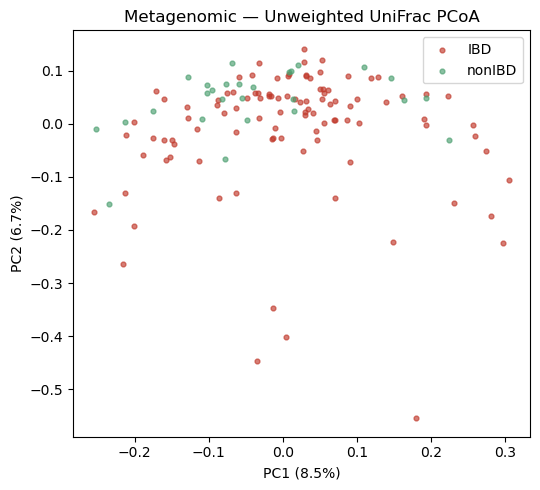

In [54]:
# --- Step 5: unweighted UniFrac + PCoA ---
print("\nStep 5: Unweighted UniFrac + PCoA")
dm = unifrac_compat(X_rare, sub_tree)
ord_res = pcoa(dm, number_of_dimensions=3)
coords = ord_res.samples.iloc[:, :2].copy()
coords.columns = ["PC1", "PC2"]
coords["group"] = m_rare.loc[coords.index, "group"]
pv1, pv2 = ord_res.proportion_explained.iloc[:2] * 100

fig, ax = plt.subplots(figsize=(5.5, 5))
for g, sub in coords.groupby("group"):
    ax.scatter(sub["PC1"], sub["PC2"], s=12, alpha=0.65,
               c=PALETTE[g], label=g)
ax.set(xlabel=f"PC1 ({pv1:.1f}%)", ylabel=f"PC2 ({pv2:.1f}%)",
       title=f"{label} — Unweighted UniFrac PCoA")
ax.legend()
plt.tight_layout(); plt.show()

In [55]:
# --- Step 6: PERMANOVA ---
print("\nStep 6: PERMANOVA (IBD vs nonIBD)")
perm = permanova(dm, m_rare["group"], permutations=999)
# pseudo-R² from one-way PERMANOVA: F = (R²/(a-1)) / ((1-R²)/(N-a))
F = perm["test statistic"]; N = perm["sample size"]; a = perm["number of groups"]
R2 = (F * (a - 1)) / (F * (a - 1) + (N - a))
print(perm)
print(f"  Pseudo-R² ≈ {R2:.3f}")


Step 6: PERMANOVA (IBD vs nonIBD)
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     130
number of groups                  2
test statistic             1.447315
p-value                       0.023
number of permutations          999
Name: PERMANOVA results, dtype: object
  Pseudo-R² ≈ 0.011


In [56]:
# --- Step 7: Random Forest classifier ---
print("\nStep 7: Random Forest classifier — 5-fold CV")
Xc = X
yc = (m["group"] == "IBD").astype(int).values
log = np.log(Xc.values + 1.0)
Xt = log - log.mean(axis=1, keepdims=True)   # CLR

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
mean_fpr = np.linspace(0, 1, 100)
tprs, aucs = [], []
for tr, te in cv.split(Xt, yc):
    clf = RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                 random_state=SEED,
                                 class_weight="balanced")
    clf.fit(Xt[tr], yc[tr])
    prob = clf.predict_proba(Xt[te])[:, 1]
    fpr, tpr, _ = roc_curve(yc[te], prob)
    interp = np.interp(mean_fpr, fpr, tpr); interp[0] = 0.0
    tprs.append(interp); aucs.append(auc(fpr, tpr))
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0

# Final fit on all data for feature importance (MDI)
clf_full = RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                  random_state=SEED,
                                  class_weight="balanced").fit(Xt, yc)
species = load_tax(TAX[label])
imp = pd.DataFrame({"feature": Xc.columns,
                    "importance": clf_full.feature_importances_})
imp["species"] = imp["feature"].map(species).fillna(imp["feature"])
imp_species = (imp.groupby("species", as_index=False)["importance"].sum()
                 .sort_values("importance", ascending=False))

results[label] = {
    "fpr": mean_fpr, "tpr": mean_tpr,
    "auc_mean": float(np.mean(aucs)), "auc_std": float(np.std(aucs)),
    "importance": imp_species,
}
print(f"  Mean ROC-AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")


Step 7: Random Forest classifier — 5-fold CV
  Mean ROC-AUC: 0.681 ± 0.161



Step 8: ROC + top features


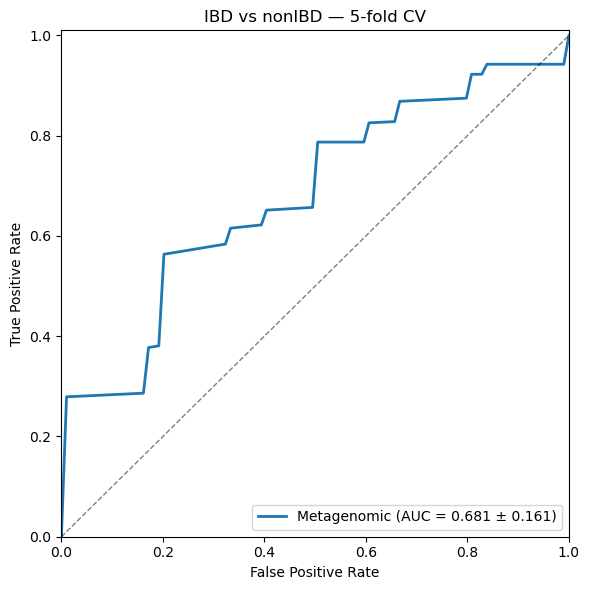

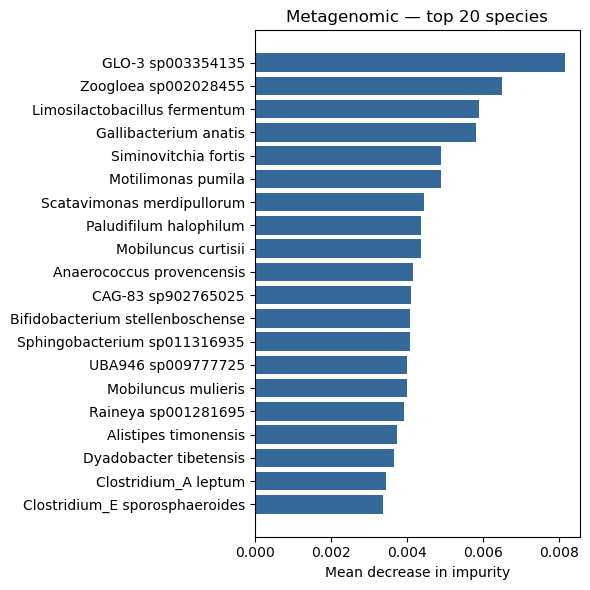

In [57]:
# ---------------------------------------------------------------------------
# Step 8: ROC curves + feature importance
# ---------------------------------------------------------------------------
print("\n" + "=" * 70, "\nStep 8: ROC + top features\n", "=" * 70, sep="")

fig, ax = plt.subplots(figsize=(6, 6))
for label, r in results.items():
    ax.plot(r["fpr"], r["tpr"], lw=2,
            label=f"{label} (AUC = {r['auc_mean']:.3f} ± {r['auc_std']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set(xlim=[0, 1], ylim=[0, 1.01],
       xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="IBD vs nonIBD — 5-fold CV")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1: axes = [axes]
for ax, (label, r) in zip(axes, results.items()):
    top = r["importance"].head(TOP_FEATURES).iloc[::-1]
    ax.barh(top["species"], top["importance"], color="#34699A")
    ax.set_title(f"{label} — top {TOP_FEATURES} species")
    ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout(); plt.show()

In [58]:
# ---------------------------------------------------------------------------
# Now for Metatranscriptomics!
# ---------------------------------------------------------------------------
label = "Metatranscriptomic"
biom_path = BIOMS[label]
print("\n" + "#" * 70, f"\n# {label}\n", "#" * 70, sep="")

# --- Step 1: load + filter ---
print("\nStep 2: Load + filter feature table")
X = load_and_filter(biom_path)

# Dedup to one random sample per subject
m_all = meta.loc[X.index]
m = (m_all.groupby("host_subject_id", group_keys=False)
          .sample(n=1, random_state=SEED))
X = X.loc[m.index]
print(f"  After per-subject dedup: {X.shape[0]} samples "
      f"({m['host_subject_id'].nunique()} subjects)")

# restrict to features present in reference phylogenetic tree (for diversity metrics)
in_tree = [f for f in X.columns if f in tree_tips]
X_tree = X[in_tree]
sub_tree = shear_tree(full_tree, in_tree)
print(f"  {len(in_tree)} / {X.shape[1]} features present in tree")


######################################################################
# Metatranscriptomic
######################################################################

Step 2: Load + filter feature table
  741 samples × 614 features after filtering
  After per-subject dedup: 104 samples (104 subjects)
  614 / 614 features present in tree


In [59]:
# --- Step 3: rarefy ---
print(f"\nStep 3: Rarefy to {RAREFY_DEPTH:,} (subsample without replacement)")
X_rare = rarefy_table(X_tree, RAREFY_DEPTH)
m_rare = m.loc[X_rare.index]
print(f"  {X_rare.shape[0]} samples retained "
      f"({(m_rare['group']=='IBD').sum()} IBD, "
      f"{(m_rare['group']=='nonIBD').sum()} nonIBD)")


Step 3: Rarefy to 5,000 (subsample without replacement)
  86 samples retained (63 IBD, 23 nonIBD)



Step 4: Alpha diversity (Shannon + Faith's PD)


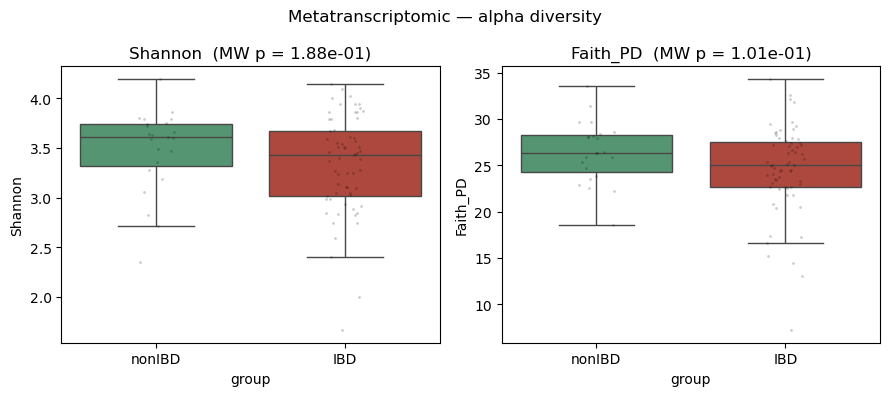

In [60]:
# --- Step 4: alpha diversity (Shannon + Faith's PD) ---
print("\nStep 4: Alpha diversity (Shannon + Faith's PD)")
shannon = alpha_diversity("shannon", X_rare.values, ids=X_rare.index)
try:
    faith = alpha_diversity("faith_pd", X_rare.values, ids=X_rare.index,
                            taxa=X_rare.columns.tolist(), tree=sub_tree,
                            validate=False)
except TypeError:
    faith = alpha_diversity("faith_pd", X_rare.values, ids=X_rare.index,
                            otu_ids=X_rare.columns.tolist(), tree=sub_tree,
                            validate=False)
alpha_df = pd.DataFrame({"Shannon": shannon, "Faith_PD": faith,
                         "group": m_rare["group"]})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, metric in zip(axes, ["Shannon", "Faith_PD"]):
    sns.boxplot(data=alpha_df, x="group", y=metric, order=["nonIBD", "IBD"],
                palette=PALETTE, ax=ax, fliersize=0)
    sns.stripplot(data=alpha_df, x="group", y=metric, order=["nonIBD", "IBD"],
                  color="black", alpha=0.2, size=2, ax=ax)
    a = alpha_df.loc[alpha_df["group"] == "nonIBD", metric]
    b = alpha_df.loc[alpha_df["group"] == "IBD", metric]
    _, p = mannwhitneyu(a, b)
    ax.set_title(f"{metric}  (MW p = {p:.2e})")
fig.suptitle(f"{label} — alpha diversity")
plt.tight_layout(); plt.show()


Step 5: Unweighted UniFrac + PCoA


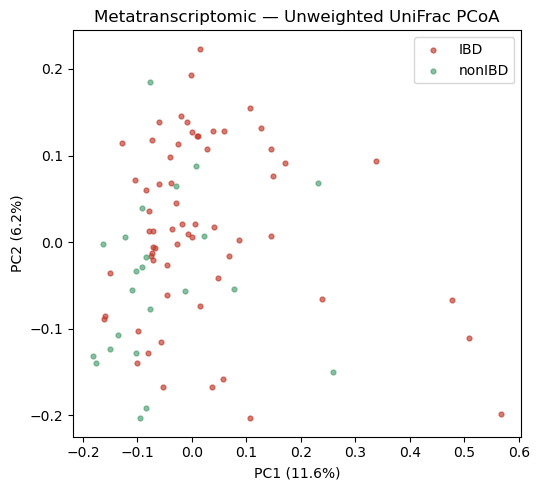

In [61]:
# --- Step 5: unweighted UniFrac + PCoA ---
print("\nStep 5: Unweighted UniFrac + PCoA")
dm = unifrac_compat(X_rare, sub_tree)
ord_res = pcoa(dm, number_of_dimensions=3)
coords = ord_res.samples.iloc[:, :2].copy()
coords.columns = ["PC1", "PC2"]
coords["group"] = m_rare.loc[coords.index, "group"]
pv1, pv2 = ord_res.proportion_explained.iloc[:2] * 100

fig, ax = plt.subplots(figsize=(5.5, 5))
for g, sub in coords.groupby("group"):
    ax.scatter(sub["PC1"], sub["PC2"], s=12, alpha=0.65,
               c=PALETTE[g], label=g)
ax.set(xlabel=f"PC1 ({pv1:.1f}%)", ylabel=f"PC2 ({pv2:.1f}%)",
       title=f"{label} — Unweighted UniFrac PCoA")
ax.legend()
plt.tight_layout(); plt.show()

In [62]:
# --- Step 6: PERMANOVA ---
print("\nStep 6: PERMANOVA (IBD vs nonIBD)")
perm = permanova(dm, m_rare["group"], permutations=999)
# pseudo-R² from one-way PERMANOVA: F = (R²/(a-1)) / ((1-R²)/(N-a))
F = perm["test statistic"]; N = perm["sample size"]; a = perm["number of groups"]
R2 = (F * (a - 1)) / (F * (a - 1) + (N - a))
print(perm)
print(f"  Pseudo-R² ≈ {R2:.3f}")


Step 6: PERMANOVA (IBD vs nonIBD)
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      86
number of groups                  2
test statistic             1.855369
p-value                       0.007
number of permutations          999
Name: PERMANOVA results, dtype: object
  Pseudo-R² ≈ 0.022


In [63]:
# --- Step 7: Random Forest classifier ---
print("\nStep 7: Random Forest classifier — 5-fold CV")
Xc = X
yc = (m["group"] == "IBD").astype(int).values
log = np.log(Xc.values + 1.0)
Xt = log - log.mean(axis=1, keepdims=True)   # CLR

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
mean_fpr = np.linspace(0, 1, 100)
tprs, aucs = [], []
for tr, te in cv.split(Xt, yc):
    clf = RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                 random_state=SEED,
                                 class_weight="balanced")
    clf.fit(Xt[tr], yc[tr])
    prob = clf.predict_proba(Xt[te])[:, 1]
    fpr, tpr, _ = roc_curve(yc[te], prob)
    interp = np.interp(mean_fpr, fpr, tpr); interp[0] = 0.0
    tprs.append(interp); aucs.append(auc(fpr, tpr))
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0

# Final fit on all data for feature importance (MDI)
clf_full = RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                  random_state=SEED,
                                  class_weight="balanced").fit(Xt, yc)
species = load_tax(TAX[label])
imp = pd.DataFrame({"feature": Xc.columns,
                    "importance": clf_full.feature_importances_})
imp["species"] = imp["feature"].map(species).fillna(imp["feature"])
imp_species = (imp.groupby("species", as_index=False)["importance"].sum()
                 .sort_values("importance", ascending=False))

results[label] = {
    "fpr": mean_fpr, "tpr": mean_tpr,
    "auc_mean": float(np.mean(aucs)), "auc_std": float(np.std(aucs)),
    "importance": imp_species,
}
print(f"  Mean ROC-AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")


Step 7: Random Forest classifier — 5-fold CV
  Mean ROC-AUC: 0.697 ± 0.080



Step 8: ROC + top features


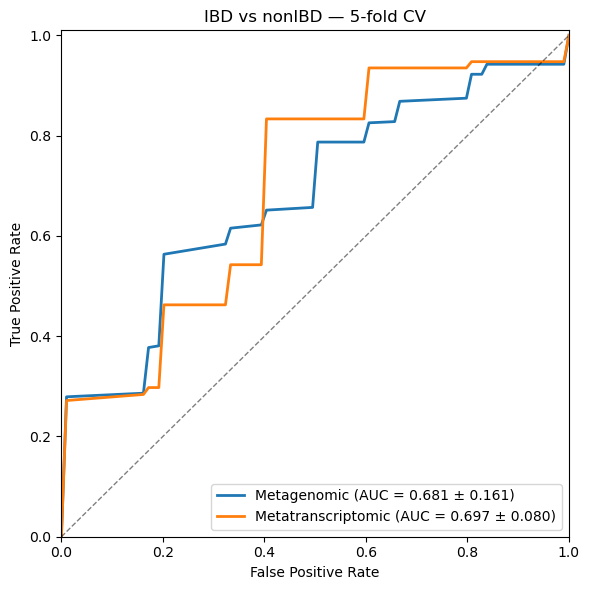

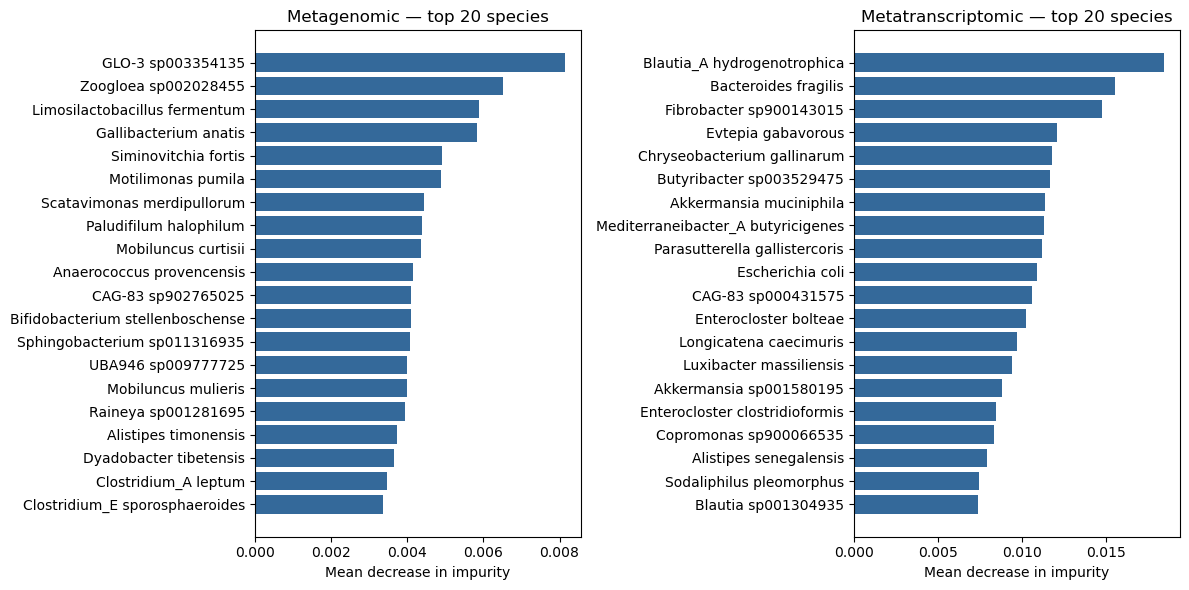

In [64]:
# ---------------------------------------------------------------------------
# Step 8: ROC curves + feature importance
# ---------------------------------------------------------------------------
print("\n" + "=" * 70, "\nStep 8: ROC + top features\n", "=" * 70, sep="")

fig, ax = plt.subplots(figsize=(6, 6))
for label, r in results.items():
    ax.plot(r["fpr"], r["tpr"], lw=2,
            label=f"{label} (AUC = {r['auc_mean']:.3f} ± {r['auc_std']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set(xlim=[0, 1], ylim=[0, 1.01],
       xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="IBD vs nonIBD — 5-fold CV")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1: axes = [axes]
for ax, (label, r) in zip(axes, results.items()):
    top = r["importance"].head(TOP_FEATURES).iloc[::-1]
    ax.barh(top["species"], top["importance"], color="#34699A")
    ax.set_title(f"{label} — top {TOP_FEATURES} species")
    ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout(); plt.show()

# Congratulations! We're done
We hope you enjoyed this walkthrough through some of the new and established microbiome analysis tools the Knight Lab has been using, and we are excited to apply it to the NPH data! Thank you for your participation!